## 0.データのフィルタリング・クリーニング 関数

### データ読み込みと結合

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# データ読み込み
df = pd.read_csv('../data/raw/RECONSTRUCTED trajectories-400-0415_NO MOTORCYCLES.csv')
# df2 = pd.read_csv('../data/raw/trajectories-0500-0515.csv')
# df3 = pd.read_csv('../data/raw/trajectories-0515-0530.csv')

# # 時間帯の識別列を追加 (id の重複があるため)
# df1['time_period'] = 1  # 4:00-4:15
# df2['time_period'] = 2  # 5:00-5:15
# df3['time_period'] = 3  # 5:15-5:30

# # 結合
# df = pd.concat([df1, df2, df3], ignore_index=True)

# データの確認
print(df.shape)
df.head()

(1048575, 10)


,Vehicle_ID,Frame_ID,Lane_ID,Local_Y,Mean_Speed,Mean_Accel,Vehicle_Length,Vehicle_Class_ID,Follower_ID,Leader_ID
0,1,147,2,164.31480,9.32100,4.80053,14.30151,2,-1,-1
1,1,148,2,165.30880,9.94003,6.19029,14.30151,2,-1,-1
2,1,149,2,166.31959,10.10781,1.67762,14.30151,2,-1,-1
3,1,150,2,167.34443,10.24859,1.40787,14.30151,2,-1,-1
4,1,151,2,168.37937,10.34925,1.00659,14.30151,2,-1,-1


In [ ]:
# 列名の確認
print(df.columns.tolist())

# データ型の確認
print(df.dtypes)

#欠損値　
print("\n欠損値:")
df.isnull().sum()

# 基本統計量
df.describe()

#v,accはfeet表示であることに注意

['Vehicle_ID', 'Frame_ID', 'Lane_ID', 'Local_Y', 'Mean_Speed', 'Mean_Accel', 'Vehicle_Length', 'Vehicle_Class_ID', 'Follower_ID', 'Leader_ID']
Vehicle_ID            int64
Frame_ID              int64
Lane_ID               int64
Local_Y             float64
Mean_Speed          float64
Mean_Accel          float64
Vehicle_Length      float64
Vehicle_Class_ID      int64
Follower_ID           int64
Leader_ID             int64
dtype: object

欠損値:


,Vehicle_ID,Frame_ID,Lane_ID,Local_Y,Mean_Speed,Mean_Accel,Vehicle_Length,Vehicle_Class_ID,Follower_ID,Leader_ID
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.730362e+03,5.286394e+03,4.153560e+00,8.157568e+02,2.501700e+01,-7.174336e-02,1.628600e+01,2.047720e+00,1.641388e+03,1.632946e+03
std,9.551057e+02,2.633862e+03,1.737985e+01,3.705799e+02,1.296960e+01,3.175487e+00,8.187463e+00,2.131733e-01,1.020032e+03,1.018615e+03
min,1.000000e+00,6.100000e+01,1.000000e+00,1.640428e+02,0.000000e+00,-4.654757e+01,8.400920e+00,2.000000e+00,-1.000000e+00,-1.000000e+00
25%,9.740000e+02,3.010000e+03,2.000000e+00,5.015013e+02,1.717428e+01,-1.340220e+00,1.380151e+01,2.000000e+00,7.660000e+02,7.580000e+02
50%,1.757000e+03,5.488000e+03,4.000000e+00,8.017110e+02,2.425158e+01,0.000000e+00,1.480151e+01,2.000000e+00,1.698000e+03,1.690000e+03
75%,2.431000e+03,7.586000e+03,5.000000e+00,1.134757e+03,3.018527e+01,1.291830e+00,1.580184e+01,2.000000e+00,2.408000e+03,2.400000e+03
max,3.343000e+03,9.956000e+03,9.990000e+02,1.496267e+03,1.037572e+02,2.527257e+01,7.620834e+01,3.000000e+00,3.366000e+03,3.366000e+03


In [ ]:
# 各列の中身を確認
print(df['Leader_ID'].head(10))
print(df['Vehicle_Class_ID'].head(10))
print(df['Local_Y'].head(10))
print(df['Mean_Speed'].head(10))

0   -1
1   -1
2   -1
3   -1
4   -1
5   -1
6   -1
7   -1
8   -1
9   -1
Name: Leader_ID, dtype: int64
0    2
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: Vehicle_Class_ID, dtype: int64
0    164.31480
1    165.30880
2    166.31959
3    167.34443
4    168.37937
5    169.42067
6    170.46579
7    171.51313
8    172.56188
9    173.61159
Name: Local_Y, dtype: float64
0     9.32100
1     9.94003
2    10.10781
3    10.24859
4    10.34925
5    10.41309
6    10.45108
7    10.47362
8    10.48750
9    10.49695
Name: Mean_Speed, dtype: float64


In [ ]:
# まず現在の型を確認
print(df[['Preceding', 'Following', 'Total_Frames', 'Space_Headway', 'Time_Headway', 'Local_Y']].dtypes)

Preceding          int64
Following          int64
Total_Frames       int64
Space_Headway    float64
Time_Headway     float64
Local_Y           object
dtype: object


In [ ]:
# Local_Yのカンマを除去して数値に変換
df['Local_Y'] = df['Local_Y'].str.replace(',', '').astype(float)

# 確認
print(df['Local_Y'].dtype)
print(df['Local_Y'].head(10))

float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Local_Y, dtype: float64


In [ ]:
# 変換前のLocal_Yの中身を確認
print(df['Local_Y'].head(10))
print(f"\nユニークな値の例:")
print(df['Local_Y'].unique()[:10])

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Local_Y, dtype: float64

ユニークな値の例:
[    nan 984.041 982.026 978.488 982.15  987.468 985.569 983.915 983.996
 985.539]


In [ ]:
print(f"NaNの数: {df['Local_Y'].isna().sum():,}")
print(f"全行数: {len(df):,}")
print(f"NaNの割合: {df['Local_Y'].isna().sum() / len(df) * 100:.2f}%")

NaNの数: 2,752,512
全行数: 4,566,387
NaNの割合: 60.28%


In [ ]:
# カンマを除去して数値に変換 
df['Preceding'] = df['Preceding'].str.replace(',', '').astype(float).astype(int)
df['Following'] = df['Following'].str.replace(',', '').astype(float).astype(int)
df['Total_Frames'] = df['Total_Frames'].str.replace(',', '').astype(float).astype(int)
df['Space_Headway'] = df['Space_Headway'].str.replace(',', '').astype(float)
df['Time_Headway'] = df['Time_Headway'].str.replace(',', '').astype(float)
df['Local_Y'] = df['Local_Y'].str.replace(',', '').astype(float)

# 確認
print(df.dtypes)

AttributeError: Can only use .str accessor with string values, not integer

In [ ]:
# 車種の分布確認
print("車種の分布:")
print(df['Vehicle_Class_ID'].value_counts())

# 車線の分布確認
print("\n車線の分布:")
print(df['Lane_ID'].value_counts().sort_index())

# 速度・加速度の基本統計
print("\n速度:")
print(df['Mean_Speed'].describe())

print("\n加速度:")
print(df['Mean_Accel'].describe())

車種の分布:
Vehicle_Class_ID
2    998537
3     50038
Name: count, dtype: int64

車線の分布:
Lane_ID
1       81441
2      199165
3      166014
4      201255
5      176823
6      193232
7       30328
999       317
Name: count, dtype: int64

速度:
count    1.048575e+06
mean     2.501700e+01
std      1.296960e+01
min      0.000000e+00
25%      1.717428e+01
50%      2.425158e+01
75%      3.018527e+01
max      1.037572e+02
Name: Mean_Speed, dtype: float64

加速度:
count    1.048575e+06
mean    -7.174336e-02
std      3.175487e+00
min     -4.654757e+01
25%     -1.340220e+00
50%      0.000000e+00
75%      1.291830e+00
max      2.527257e+01
Name: Mean_Accel, dtype: float64


### すべての追従ペアにペアIDを付与　(df_with_pairsを作成)

In [ ]:
def give_pair_id(df):
    # ソート
    df = df.sort_values(['Vehicle_ID', 'Frame_ID']).copy()
    
    # 条件が途切れるタイミングを検出
    # ① Leader_IDが変わった
    preceding_changed = df.groupby('Vehicle_ID')['Leader_ID'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    # ② Leader_ID=0
    preceding_zero = df['Leader_ID'] == 0
    
    # 条件が途切れるタイミング
    break_point = preceding_changed | preceding_zero
    
    # ペアIDを付与
    df['pair_id'] = break_point.cumsum()
    
    # Leader_ID=0の行はpair_idをNaNにする
    df.loc[preceding_zero, 'pair_id'] = None
    
    return df

# 実行
df_with_pairs = give_pair_id(df)

# 確認
print(f"総行数: {len(df_with_pairs):,}")
print(f"追従ペア数: {df_with_pairs['pair_id'].nunique():,}")
df_with_pairs[['Vehicle_ID', 'Frame_ID', 'Lane_ID', 'Leader_ID', 'pair_id']].head(20)

総行数: 1,048,575
追従ペア数: 6,266


,Vehicle_ID,Frame_ID,Lane_ID,Leader_ID,pair_id
0,1,147,2,-1,0.0
1,1,148,2,-1,0.0
2,1,149,2,-1,0.0
3,1,150,2,-1,0.0
4,1,151,2,-1,0.0
5,1,152,2,-1,0.0
6,1,153,2,-1,0.0
7,1,154,2,-1,0.0
8,1,155,2,-1,0.0
9,1,156,2,-1,0.0


In [ ]:
# 各フラグの確認用
def give_pair_id_debug(df):
    # ソート
    df = df.sort_values(['Vehicle_ID', 'Global_Time']).copy()
    
    # 条件が途切れるタイミングを検出
    # ① Precedingが変わった
    preceding_changed = df.groupby('Vehicle_ID')['Preceding'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    # ② Preceding=0
    preceding_zero = df['Preceding'] == 0
    
    # 条件が途切れるタイミング
    break_point = preceding_changed | preceding_zero
    
    df['preceding_changed'] = preceding_changed
    df['preceding_zero'] = preceding_zero
    df['break_point'] = break_point
    
    # ペアIDを付与
    df['pair_id'] = break_point.cumsum()
    
    # Preceding=0の行はpair_idをNaNにする
    df.loc[preceding_zero, 'pair_id'] = None

    return df

# デバッグ用実行
df_debug = give_pair_id_debug(df)

# 確認
print(f"総行数: {len(df_debug):,}")
print(f"追従ペア数: {df_debug['pair_id'].nunique():,}")
print("\n最初の20行:")
print(df_debug[['Vehicle_ID', 'Global_Time', 'Lane_ID', 'Preceding', 
                'preceding_changed', 'preceding_zero', 'break_point', 'pair_id']].head(20))

総行数: 4,566,387
追従ペア数: 14,770

最初の20行:
       Vehicle_ID    Global_Time  Lane_ID  Preceding  preceding_changed  \
3512            1  1113433136100        2          0               True   
3780            1  1113433136200        2          0              False   
4093            1  1113433136300        2          0              False   
4428            1  1113433136400        2          0              False   
4791            1  1113433136500        2          0              False   
5213            1  1113433136600        2          0              False   
5634            1  1113433136700        2          0              False   
6097            1  1113433136800        2          0              False   
6588            1  1113433136900        2          0              False   
7146            1  1113433137000        2          0              False   
7814            1  1113433137100        2          0              False   
8690            1  1113433137200        2          0          

In [ ]:
# デバッグデータをCSV出力
df_debug.to_csv('../results/debug.csv', index=False)

print(f"出力行数: {len(df_debug):,}行")
print("出力先: ../results/debug.csv")

出力行数: 4,566,387行
出力先: ../results/debug.csv


### 車線フィルタ

In [ ]:
print(df['Lane_ID'].value_counts().sort_index())

Lane_ID
1       81441
2      199165
3      166014
4      201255
5      176823
6      193232
7       30328
999       317
Name: count, dtype: int64


In [ ]:
def filter_lane(df, lanes=[2, 3, 4]):
    """
    車線フィルタ
    lanes: 使用する車線のリスト（デフォルト: Lane 2,3,4）
    """
    df_filtered = df[df['Lane_ID'].isin(lanes)]
    
    print(f"フィルタ前: {len(df):,}行")
    print(f"フィルタ後: {len(df_filtered):,}行")
    print(f"除外された行数: {len(df) - len(df_filtered):,}行")
    print(f"\n車線の分布:")
    print(df_filtered['Lane_ID'].value_counts().sort_index())
    
    return df_filtered

# 実行
#df_lane = filter_lane(df)

In [ ]:
# 実行
df_lane_with_pairs = filter_lane(df_with_pairs)

# # 車線フィルタ後のデータにペアIDを付与
# df_lane_with_pairs = give_pair_id(df_lane)

# 追従ペア数の確認
print(f"追従ペア数: {df_lane_with_pairs['pair_id'].nunique():,}")

フィルタ前: 1,048,575行
フィルタ後: 566,434行
除外された行数: 482,141行

車線の分布:
Lane_ID
2    199165
3    166014
4    201255
Name: count, dtype: int64
追従ペア数: 2,851


### 追従時間フィルタ

In [ ]:
def filter_duration(df, min_duration=60):
    """
    追従時間フィルタ
    min_duration: 最小追従時間（秒）（デフォルト: 60秒）
    """
    # 各ペアの追従時間を計算
    # Frame_IDは0.1秒間隔なので、差分×0.1で秒に変換
    pair_duration = df.groupby('pair_id')['Frame_ID'].agg(
        duration=lambda x: (x.max() - x.min()) * 0.1  # フレーム→秒
    )
    
    # min_duration以上のペアIDを取得
    valid_pair_ids = pair_duration[pair_duration['duration'] >= min_duration].index
    
    # 有効なペアIDの行だけ残す
    df_filtered = df[df['pair_id'].isin(valid_pair_ids)]
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"除外されたペア数: {df['pair_id'].nunique() - df_filtered['pair_id'].nunique():,}")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    
    return df_filtered

# 実行
df_duration = filter_duration(df_lane_with_pairs)

フィルタ前のペア数: 2,851
フィルタ後のペア数: 167
除外されたペア数: 2,684

フィルタ前の行数: 566,434
フィルタ後の行数: 111,261


### 加速度フィルタ
加速度・減速度が1m/s^2 を超えた部分のみを削除する  <br>
NGSIMの単位: feet/s^2<br>
1 feet = 0.3048 m , 1 m = 3.28084 feet<br>
よって、1m/s^2 / 0.3048 = 3.28084 feet /s^2 を超える部分を削除する


In [ ]:
def filter_acceleration(df, max_acc=1.0):
    """
    加速度フィルタ
    max_acc: 最大加速度・減速度（m/s²）（デフォルト: 1.0 m/s²）
    """
    # 閾値をfeet/s²に変換
    max_acc_feet = max_acc / 0.3048
    
    # 閾値を超える行を除外
    df_filtered = df[df['v_Acc'].abs() <= max_acc_feet]
    
    print(f"閾値: {max_acc} m/s² = {max_acc_feet:.4f} feet/s²")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nフィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_acc = filter_acceleration(df_duration)

閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,456,082
フィルタ後の行数: 1,066,480
除外された行数: 389,602

フィルタ前のペア数: 1,535
フィルタ後のペア数: 1,535


### カットオフウィンドウ

In [ ]:
print(df_acc['pair_id'].head(10))
print(f"NaNの数: {df_acc['pair_id'].isna().sum():,}")
print(f"ユニークなpair_id数: {df_acc['pair_id'].nunique():,}")

816169    7823.0
823029    7823.0
829864    7823.0
836628    7823.0
843560    7823.0
863171    7823.0
869045    7823.0
875750    7823.0
893900    7823.0
918517    7823.0
Name: pair_id, dtype: float64
NaNの数: 0
ユニークなpair_id数: 1,535


In [ ]:
def apply_cutoff(df, cutoff=10):
    """
    カットオフウィンドウ
    cutoff: カットオフ時間（秒）（デフォルト: 10秒）
    """
    cutoff_ms = cutoff * 1000  # 秒→ミリ秒
    
    # ペアごとの最小・最大時刻を計算
    pair_times = df.groupby('pair_id')['Global_Time'].agg(
        min_time='min',
        max_time='max'
    ).reset_index()
    
    # 元のデータに結合
    df_merged = df.merge(pair_times, on='pair_id')
    
    # カットオフ条件でフィルタリング
    df_filtered = df_merged[
        (df_merged['Global_Time'] >= df_merged['min_time'] + cutoff_ms) &
        (df_merged['Global_Time'] <= df_merged['max_time'] - cutoff_ms)
    ].drop(columns=['min_time', 'max_time'])
    
    print(f"カットオフ前の行数: {len(df):,}")
    print(f"カットオフ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nカットオフ前のペア数: {df['pair_id'].nunique():,}")
    print(f"カットオフ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_cutoff = apply_cutoff(df_acc)

カットオフ前の行数: 1,066,480
カットオフ後の行数: 861,884
除外された行数: 204,596

カットオフ前のペア数: 1,535
カットオフ後のペア数: 1,535


In [ ]:
# ペアごとの追従時間の分布を確認
pair_times = df_acc.groupby('pair_id')['Global_Time'].agg(
    duration=lambda x: (x.max() - x.min()) / 1000
)
print(pair_times['duration'].describe())
print(f"\n20秒以下のペア数: {len(pair_times[pair_times['duration'] <= 20]):,}")

count    1535.000000
mean       94.583127
std        35.588883
min        59.100000
25%        68.500000
50%        80.900000
75%       107.550000
max       216.900000
Name: duration, dtype: float64

20秒以下のペア数: 0


In [ ]:
# 元データから前方車両の車種を取得
leader_class = df[['Vehicle_ID', 'v_Class']].drop_duplicates()
leader_class = leader_class.rename(columns={'Vehicle_ID': 'Preceding', 'v_Class': 'leader_class'})

# 結合
df_final['ego_class'] = df_final['v_Class']
df_final = df_final.merge(leader_class, on='Preceding', how='left')

# 追従タイプを定義
def get_pair_type(ego, leader):
    ego_name = 'Car' if ego == 2 else 'Truck'
    leader_name = 'Car' if leader == 2 else 'Truck'
    return f'{ego_name}-{leader_name}'

df_final['pair_type'] = df_final.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['Car-Car', 'Car-Truck', 'Truck-Truck', 'Truck-Car']

# ペア数と軌跡数の集計
pairs_count = df_final.groupby(['pair_id', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order)
trajectory_summary = df_final.groupby('pair_type').size().reindex(order)

print("追従ペア数:")
print(pairs_summary)
print("\n軌跡データ件数:")
print(trajectory_summary)

追従ペア数:
pair_type
Car-Car        1471
Car-Truck       146
Truck-Truck       9
Truck-Car        52
dtype: int64

軌跡データ件数:
pair_type
Car-Car        827864
Car-Truck       81178
Truck-Truck      5349
Truck-Car       28181
dtype: int64


In [ ]:
# ② 車線フィルタ
df_lane = filter_lane(df)

# ③ ペアID付与
df_with_pairs = give_pair_id(df_lane)

# ④ 車種フィルタ
df_lane_class = filter_class(df_with_pairs)

# ⑤ 追従時間フィルタ（60秒以上）
df_duration = filter_duration(df_lane_class)

# ⑥ 加速度フィルタ
df_acc = filter_acceleration(df_duration)

# ⑦ カットオフウィンドウ（前後10秒）
df_final = apply_cutoff(df_acc)

# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")

フィルタ前: 4,566,387行
フィルタ後: 2,430,711行
除外された行数: 2,135,676行

車線の分布:
Lane_ID
2    830690
3    719832
4    880189
Name: count, dtype: int64
フィルタ前: 2,430,711行
フィルタ後: 2,428,817行
除外された行数: 1,894行

車種の分布:
v_Class
2    2313342
3     115475
Name: count, dtype: int64
フィルタ前のペア数: 6,106
フィルタ後のペア数: 1,539
除外されたペア数: 4,567

フィルタ前の行数: 2,428,817
フィルタ後の行数: 1,459,265
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,459,265
フィルタ後の行数: 1,068,730
除外された行数: 390,535

フィルタ前のペア数: 1,539
フィルタ後のペア数: 1,539
カットオフ前の行数: 1,068,730
カットオフ後の行数: 863,730
除外された行数: 205,000

カットオフ前のペア数: 1,539
カットオフ後のペア数: 1,538

===最終結果===
行数: 863,730
ペア数: 1,538


## 実行と確認

In [ ]:
print(f"元のデータ:         {len(df):,}行")
print(f"車線・車種フィルタ後: {len(df_filtered):,}行")
print(f"加速度フィルタ後:    {len(df_acc):,}行")
print(f"60秒フィルタ後:     {len(df_valid):,}行")
print(f"カットオフ後:        {len(df_cutoff):,}行")
print(f"車線変更除外後:      {len(df_no_lc):,}行")

元のデータ:         4,566,387行


NameError: name 'df_filtered' is not defined

In [ ]:
# 車種の対応
# v_Class: 2=車(Car), 3=トラック(Truck)

# 各ペアの車種を特定
df_no_lc['ego_class'] = df_no_lc['v_Class']  # 自車の車種

# 前方車両の車種を結合
leader_class = df_no_lc[['Vehicle_ID', 'time_period', 'v_Class']].drop_duplicates()
leader_class = leader_class.rename(columns={'Vehicle_ID': 'Preceding', 'v_Class': 'leader_class'})

df_no_lc = df_no_lc.merge(leader_class, on=['Preceding', 'time_period'], how='left')

# 追従タイプを定義
def get_pair_type(ego, leader):
    ego_name = 'Car' if ego == 2 else 'Truck'
    leader_name = 'Car' if leader == 2 else 'Truck'
    return f'{ego_name}-{leader_name}'

df_no_lc['pair_type'] = df_no_lc.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['Car-Car', 'Car-Truck', 'Truck-Truck', 'Truck-Car']

# ペア数と軌跡数の集計
pairs_count = df_no_lc.groupby(['Vehicle_ID', 'Preceding', 'time_period', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order)
trajectory_summary = df_no_lc.groupby('pair_type').size().reindex(order)

print("追従ペア数:")
print(pairs_summary)
print("\n軌跡データ件数:")
print(trajectory_summary)

追従ペア数:
pair_type
Car-Car        898
Car-Truck      249
Truck-Truck     14
Truck-Car       26
dtype: int64

軌跡データ件数:
pair_type
Car-Car        418440
Car-Truck       94042
Truck-Truck      5920
Truck-Car       11275
dtype: int64


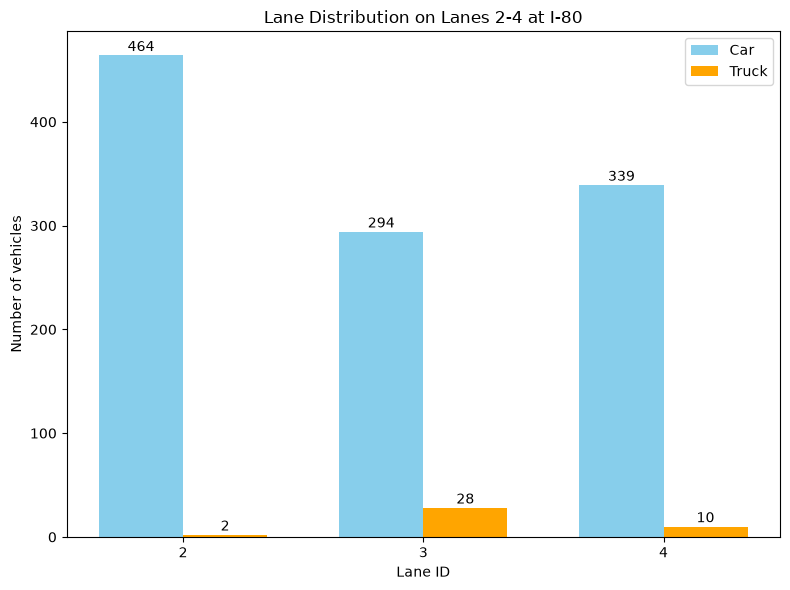

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# フィルタリング後のデータ（df_no_lc）から車線ごとの車両数を集計
df_unique = df_no_lc.drop_duplicates(subset=['Vehicle_ID', 'time_period', 'Lane_ID'])

# 車線ごと・車種ごとの車両数
lane_class = df_unique.groupby(['Lane_ID', 'v_Class'])['Vehicle_ID'].nunique().reset_index()

# 車(v_Class=2)とトラック(v_Class=3)に分ける
cars = lane_class[lane_class['v_Class'] == 2]
trucks = lane_class[lane_class['v_Class'] == 3]

# グラフ描画
x = np.array([2, 3, 4])
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars_car = ax.bar(x - width/2, cars['Vehicle_ID'].values, width, label='Car', color='skyblue')
bars_truck = ax.bar(x + width/2, trucks['Vehicle_ID'].values, width, label='Truck', color='orange')

# 値をバーの上に表示
for bar in bars_car:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

for bar in bars_truck:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

ax.set_xlabel('Lane ID')
ax.set_ylabel('Number of vehicles')
ax.set_xticks(x)
ax.legend()
ax.set_title('Lane Distribution on Lanes 2-4 at I-80')
plt.tight_layout()
plt.show()

In [ ]:
# 同じVehicle_IDで複数のv_Classが存在するか確認
check = df_no_lc.groupby(['Vehicle_ID', 'time_period'])['v_Class'].nunique()
print(check[check > 1])

Series([], Name: v_Class, dtype: int64)


In [ ]:
# Precedingの車両がdf_no_lcに存在しない場合を確認
preceding_ids = df_no_lc[['Preceding', 'time_period']].drop_duplicates()
vehicle_ids = df_no_lc[['Vehicle_ID', 'time_period']].drop_duplicates()
vehicle_ids = vehicle_ids.rename(columns={'Vehicle_ID': 'Preceding'})

# マッチしないPrecedingを確認
unmatched = preceding_ids.merge(vehicle_ids, on=['Preceding', 'time_period'], how='left', indicator=True)
print(unmatched[unmatched['_merge'] == 'left_only'])
print(f"\nマッチしないペア数: {len(unmatched[unmatched['_merge'] == 'left_only'])}")

      Preceding  time_period     _merge
0             3            3  left_only
1             4            3  left_only
2             5            3  left_only
3             1            1  left_only
4            15            1  left_only
...         ...          ...        ...
1145       2493            1  left_only
1160       2833            1  left_only
1170       2874            1  left_only
1173       2890            1  left_only
1174       2924            1  left_only

[226 rows x 3 columns]

マッチしないペア数: 226


In [ ]:
# 元データから前方車両の車種を取得
leader_class = df[['Vehicle_ID', 'time_period', 'v_Class']].drop_duplicates()
leader_class = leader_class.rename(columns={'Vehicle_ID': 'Preceding', 'v_Class': 'leader_class'})

# 余分な列を削除してリセット
df_no_lc = df_no_lc.drop(columns=['ego_class', 'leader_class', 'pair_type'], errors='ignore')

# 結合
df_no_lc['ego_class'] = df_no_lc['v_Class']
df_no_lc = df_no_lc.merge(leader_class, on=['Preceding', 'time_period'], how='left')

# 追従タイプを定義
def get_pair_type(ego, leader):
    ego_name = 'Car' if ego == 2 else 'Truck'
    leader_name = 'Car' if leader == 2 else 'Truck'
    return f'{ego_name}-{leader_name}'

df_no_lc['pair_type'] = df_no_lc.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['Car-Car', 'Car-Truck', 'Truck-Truck', 'Truck-Car']

pairs_count = df_no_lc.groupby(['Vehicle_ID', 'Preceding', 'time_period', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order)
trajectory_summary = df_no_lc.groupby('pair_type').size().reindex(order)

print("追従ペア数:")
print(pairs_summary)
print("\n軌跡データ件数:")
print(trajectory_summary)

追従ペア数:
pair_type
Car-Car        1092
Car-Truck        55
Truck-Truck       5
Truck-Car        35
dtype: int64

軌跡データ件数:
pair_type
Car-Car        487964
Car-Truck       24518
Truck-Truck      2287
Truck-Car       14908
dtype: int64


In [ ]:
# Precedingが途中で変わっているケースを確認
# 同じVehicle_IDで複数のPrecedingがある場合
multi_preceding = df_no_lc.groupby(['Vehicle_ID', 'time_period'])['Preceding'].nunique()
print(f"複数のPrecedingを持つ車両数: {len(multi_preceding[multi_preceding > 1])}")
print(multi_preceding[multi_preceding > 1].head(10))

複数のPrecedingを持つ車両数: 12
Vehicle_ID  time_period
22          3              2
667         3              2
810         3              2
1540        3              2
1559        3              2
1735        3              2
1742        3              2
1748        3              2
1750        3              2
1875        2              2
Name: Preceding, dtype: int64


### 04.追従時間フィルタ
追従時間が60s以上のペアだけを使用する<br>
NGSIMのデータ: Preceding(同一車線の先頭車両)前にいる車のID<br>
その車両は、前にいる車を追従している。<br>


In [ ]:
# 追従ペアの抽出

# Preceding=0は前方車両なし → 除外
df_following = df_acc[df_acc['Preceding'] != 0].copy()

# Global_Timeでソート 
df_following = df_following.sort_values(['Vehicle_ID', 'time_period', 'Global_Time'])

# Precedingが変わったタイミングを車両ごとに検出　現在の行の一行前のprecedingが現在と違えば変わっているためTrue
df_following['preceding_changed'] = (
    df_following.groupby(['Vehicle_ID', 'time_period'])['Preceding']
    .transform(lambda x: x != x.shift(fill_value=-1))
)

# 区間IDを付与　preceding_changed=trueのたびに区間IDを付与
df_following['segment_id'] = (
    df_following.groupby(['Vehicle_ID', 'time_period'])['preceding_changed']
    .transform('cumsum')
)

# (Vehicle_ID, Preceding, time_period, segment_id)でグループ化
pairs = df_following.groupby(['Vehicle_ID', 'Preceding', 'time_period', 'segment_id'])

print(f"car-following抽出前: {len(df_acc):,}行")
print(f"car-following抽出後: {len(df_following):,}行")
print(f"car-followingペア数: {len(pairs)}")

car-following抽出前: 1,168,099行
car-following抽出後: 1,125,161行
car-followingペア数: 4741


In [ ]:
# 各グループの追従時間を計算　
following_duration = pairs['Global_Time'].agg(#グループごとに計算処理
    duration=lambda x: (x.max() - x.min()) / 1000  # ミリ秒→秒 計算結果の列名duration 
)

print(following_duration.head(10))
print(f"\n追従時間の基本統計:")
print(following_duration.describe())

print(f"\n全ペア数: {len(following_duration):,}")
print(f"60秒以上のペア数: {len(following_duration[following_duration['duration'] >= 60]):,}")

                                             duration
Vehicle_ID Preceding time_period segment_id          
1          3355      1           1                7.6
3          9         3           1               31.5
8          3         3           1               83.2
9          4         3           1               94.7
           29        3           2               19.5
10         5         3           1               70.3
11         1         1           1               83.8
12         5         3           1               63.4
           10        3           3                3.5
           21        3           2               30.9

追従時間の基本統計:
          duration
count  4741.000000
mean     33.906918
std      32.011268
min       0.000000
25%       6.700000
50%      23.000000
75%      57.100000
max     182.900000

全ペア数: 4,741
60秒以上のペア数: 1,081


In [ ]:
# 何もフィルタリングしていないデータのペア数
df_raw = df[df['Preceding'] != 0].copy()
df_raw = df_raw.sort_values(['Vehicle_ID', 'time_period', 'Global_Time'])
df_raw['preceding_changed'] = (
    df_raw.groupby(['Vehicle_ID', 'time_period'])['Preceding']
    .transform(lambda x: x != x.shift(fill_value=-1))
)
df_raw['segment_id'] = (
    df_raw.groupby(['Vehicle_ID', 'time_period'])['preceding_changed']
    .transform('cumsum')
)
pairs_raw = df_raw.groupby(['Vehicle_ID', 'Preceding', 'time_period', 'segment_id'])
duration_raw = pairs_raw['Global_Time'].agg(
    duration=lambda x: (x.max() - x.min()) / 1000
)
print(f"全ペア数（フィルタなし）: {len(duration_raw):,}")
print(f"60秒以上（フィルタなし）: {len(duration_raw[duration_raw['duration'] >= 60]):,}")
print(f"\n追従時間の分布:")
print(duration_raw['duration'].describe())

全ペア数（フィルタなし）: 11,140
60秒以上（フィルタなし）: 1,402

追従時間の分布:
count    11140.000000
mean        26.754829
std         27.061733
min          0.000000
25%          5.400000
50%         18.500000
75%         39.700000
max        182.900000
Name: duration, dtype: float64


In [ ]:
# 何もフィルタリングしていないデータのペア数（Following使用）
df_raw_following = df[df['Following'] != 0].copy()
df_raw_following = df_raw_following.sort_values(['Vehicle_ID', 'time_period', 'Global_Time'])
df_raw_following['following_changed'] = (
    df_raw_following.groupby(['Vehicle_ID', 'time_period'])['Following']
    .transform(lambda x: x != x.shift(fill_value=-1))
)
df_raw_following['segment_id'] = (
    df_raw_following.groupby(['Vehicle_ID', 'time_period'])['following_changed']
    .transform('cumsum')
)
pairs_raw_following = df_raw_following.groupby(['Vehicle_ID', 'Following', 'time_period', 'segment_id'])
duration_raw_following = pairs_raw_following['Global_Time'].agg(
    duration=lambda x: (x.max() - x.min()) / 1000
)
print(f"全ペア数（Following・フィルタなし）: {len(duration_raw_following):,}")
print(f"60秒以上（Following・フィルタなし）: {len(duration_raw_following[duration_raw_following['duration'] >= 60]):,}")
print(f"\n追従時間の分布:")
print(duration_raw_following['duration'].describe())

全ペア数（Following・フィルタなし）: 11,318
60秒以上（Following・フィルタなし）: 1,389

追従時間の分布:
count    11318.000000
mean        26.492154
std         26.997259
min          0.000000
25%          5.300000
50%         18.200000
75%         39.100000
max        182.900000
Name: duration, dtype: float64


In [ ]:
# 60秒以上の追従ペアのみ残す
valid_pairs = following_duration[following_duration['duration'] >= 60]

print(f"全ペア数: {len(following_duration):,}")
print(f"60秒以上のペア数: {len(valid_pairs):,}")

全ペア数: 4,226
60秒以上のペア数: 1,202


In [ ]:
# valid_pairsのインデックスをdf_followingに結合
df_valid = df_following.join(valid_pairs, on=['Vehicle_ID', 'Preceding', 'time_period'])

# durationがNaN（60秒未満のペア）を除外
df_valid = df_valid.dropna(subset=['duration'])

print(f"60秒フィルタ後の行数: {len(df_valid):,}")

60秒フィルタ後の行数: 686,120


##### 確認


In [ ]:
#適当な車両を1つ選んで確認
vehicle_id = 1000

# 車両1000のデータ
print("車両1000のデータ:")
print(df[df['Vehicle_ID'] == vehicle_id][['Vehicle_ID', 'Global_Time', 'Preceding', 'Following', 'Lane_ID']].head(10))

# Precedingを取得
preceding_id = df[df['Vehicle_ID'] == vehicle_id]['Preceding'].iloc[0]

# 同じGlobal_Timeのデータフレームidではファイルで統合したときに重複するため、global_timeをつかう
times = df[df['Vehicle_ID'] == vehicle_id]['Global_Time'].values

print(f"\n車両{preceding_id}の同じ時刻のデータ:")
print(df[(df['Vehicle_ID'] == preceding_id) & 
         (df['Global_Time'].isin(times))][['Vehicle_ID', 'Global_Time', 'Preceding', 'Following', 'Lane_ID']].head(10))

車両1000のデータ:
         Vehicle_ID    Global_Time  Preceding  Following  Lane_ID
1374124        1000  1113436987400        996          0        4
1374125        1000  1113436987500        996          0        4
1374126        1000  1113436987600        996          0        4
1374127        1000  1113436987700        996          0        4
1374128        1000  1113436987800        996          0        4
1374129        1000  1113436987900        996          0        4
1374130        1000  1113436988000        996          0        4
1374131        1000  1113436988100        996          0        4
1374132        1000  1113436988200        996          0        4
1374133        1000  1113436988300        996          0        4

車両996の同じ時刻のデータ:
         Vehicle_ID    Global_Time  Preceding  Following  Lane_ID
1371262         996  1113436987400        986       1000        4
1371263         996  1113436987500        986       1000        4
1371264         996  1113436987600        986  